In [90]:
from photutils import DAOStarFinder
from astropy.io import fits
from matplotlib import pyplot as plt
from photutils import aperture_photometry, CircularAperture, CircularAnnulus
import numpy as np
from glob import glob

%matplotlib inline

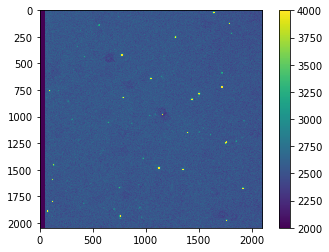

In [47]:
image= fits.open("O120308_0175.fits")
image_pixels = image[0].data

plt.imshow(image_pixels, vmin=2000, vmax=4000)
plt.colorbar()

In [32]:
daofind = DAOStarFinder(fwhm=4., threshold=1000)
starlist = daofind(image_pixels)

24


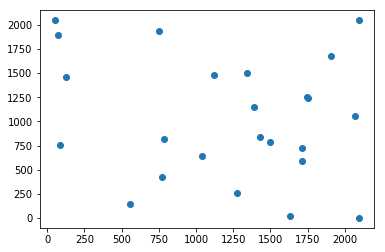

In [34]:
plt.scatter(starlist['xcentroid'], starlist['ycentroid'])
print (len(starlist))

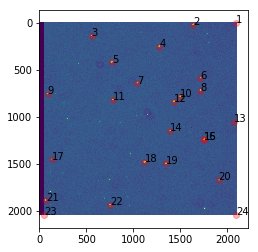

In [74]:
plt.imshow(image_pixels, vmin=2000, vmax=4000)
for row in starlist:
    plt.scatter(row['xcentroid'], row['ycentroid'], alpha=0.3, color='red')
    plt.text(row['xcentroid'], row['ycentroid'], row['id'])
    
#plt.xlim(1200,1800)
#plt.ylim(500,1000)

B = 19
C = 18
D = 12

In [57]:
positions = np.transpose((starlist['xcentroid'], starlist['ycentroid']))

aperture = CircularAperture(positions, r=6.)
annulus_aperture = CircularAnnulus(positions, r_in=10., r_out=15.)
apers = [aperture, annulus_aperture]

phot_table = aperture_photometry(image, apers)

bkg_mean = phot_table['aperture_sum_1'] / annulus_aperture.area
bkg_sum = bkg_mean * aperture.area

final_sum = phot_table['aperture_sum_0'] - bkg_sum

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Changed DATE-OBS from '2012-03-09        ' to '2012-03-09T00:00:00.0''. [astropy.wcs.wcs]


In [61]:
magnitudes = -2.5*np.log10(final_sum)
magnitudes

-11.874471131332811
-14.49866778563053
-12.949797988042366
-14.416270192782804
-15.53716944194204
-12.850358769667952
-14.628445905894495
-14.736242795064832
-13.6358570514556
-14.911435793618368
-13.444282065652327


In [62]:
starlist

id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,sky,peak,flux,mag
int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64
1,2095.372098528767,1.5880325151827224,0.24861676829822807,0.3749769233723917,-0.024628957726784754,25,0.0,2435.0,2.5090643855581147,-0.998779514918479
2,1633.6214255960404,24.192997297774614,0.4332181099274198,-0.1738681356136615,-0.5222609900362735,25,0.0,14872.0,4.831483215008578,-1.7102011877533099
3,554.7284681507963,141.4386887934629,0.39972670859964093,-0.1453232148512913,-0.17289142024600734,25,0.0,5681.0,1.3817949787189658,-0.3511090254387138
4,1273.542736781841,255.7537172050742,0.3622933445775308,-0.21548901565588793,-0.4618628263917877,25,0.0,13688.0,4.44702768169719,-1.6201745820948585
5,769.504270160087,421.28979208173547,0.3871545168110291,-0.22686312276297133,-0.28491561662262815,25,0.0,35392.0,13.74908521204345,-2.845684508946977
6,1711.095562406336,591.3537292066169,0.43394379921672543,-0.18875035389810743,-0.4370947772289892,25,0.0,5187.0,1.0088416058989083,-0.009557461964968888
7,1042.5042835591382,643.4324436873675,0.4055162539620024,-0.2142129767932362,-0.33082187728593454,25,0.0,16529.0,5.754463903877824,-1.900012175504264
8,1710.0302920134645,722.7827237284058,0.3702715021256582,-0.23657329799854027,-0.5424485352379274,25,0.0,17124.0,5.490441243628424,-1.8490181206755751
9,89.04659629667336,757.6847324818489,0.42929586277180753,-0.23107756900344273,-0.10706059718403188,25,0.0,8251.0,2.30258703873935,-0.9055401392240798


In [68]:
ZP_B = 15.1 - magnitudes[19-1]  # B (15.1)
ZP_C = 13.7 - magnitudes[18-1]    # C (13.7)
ZP_D = 13.7 - magnitudes[12-1]    # D (13.7)

In [69]:
print (ZP_B, ZP_C, ZP_D)

29.232060229480453 29.245805651036385 28.38970121659054


In [73]:
avg_ZP = np.average([ZP_B, ZP_C])
avg_ZP

29.23893294025842

In [75]:
mag_NNSer = magnitudes[14-1] + avg_ZP

In [76]:
print (mag_NNSer)

15.847790370926027


In [82]:
apers

[<CircularAperture([[2.09537210e+03, 1.58803252e+00],
                    [1.63362143e+03, 2.41929973e+01],
                    [5.54728468e+02, 1.41438689e+02],
                    [1.27354274e+03, 2.55753717e+02],
                    [7.69504270e+02, 4.21289792e+02],
                    [1.71109556e+03, 5.91353729e+02],
                    [1.04250428e+03, 6.43432444e+02],
                    [1.71003029e+03, 7.22782724e+02],
                    [8.90465963e+01, 7.57684732e+02],
                    [1.49542571e+03, 7.85642439e+02],
                    [7.82630318e+02, 8.22567601e+02],
                    [1.42914433e+03, 8.39408841e+02],
                    [2.06645054e+03, 1.05317210e+03],
                    [1.38817655e+03, 1.15111573e+03],
                    [1.75203032e+03, 1.24134545e+03],
                    [1.74616548e+03, 1.24912450e+03],
                    [1.28457211e+02, 1.45482537e+03],
                    [1.11743503e+03, 1.48234355e+03],
                    [1.34466

In [84]:
files = glob("O*")

results =[]

for file in files:
    
    print (file)
    
    image= fits.open(file)
    image_pixels = image[0].data

    phot_table = aperture_photometry(image, apers)

    bkg_mean = phot_table['aperture_sum_1'] / annulus_aperture.area
    bkg_sum = bkg_mean * aperture.area

    final_sum = phot_table['aperture_sum_0'] - bkg_sum
    
    magnitudes = -2.5*np.log10(final_sum)
    
    ZP_B = 15.1 - magnitudes[19-1]  # B (15.1)
    ZP_C = 13.7 - magnitudes[18-1]    # C (13.7)
    ZP_D = 13.7 - magnitudes[12-1]    # D (13.7)
    
    avg_ZP = np.average([ZP_B, ZP_C])
    mag_NNSer = magnitudes[14-1] + avg_ZP
    
    results.append(mag_NNSer)
    print (mag_NNSer)

O120308_0183.fits
15.846328744293832
O120308_0176.fits
15.849566353869267
O120308_0177.fits
15.83363671771065
O120308_0182.fits
15.856052177589493
O120308_0189.fits
15.85484079552602
O120308_0185.fits
15.848487414560541
O120308_0192.fits


 [astropy.io.fits.verify]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Changed DATE-OBS from '2012-03-09        ' to '2012-03-09T00:00:00.0''. [astropy.wcs.wcs]
/Users/mf/anaconda2/envs/astroconda3/lib/python3.6/site-packages/ipykernel_launcher.py:19: RuntimeWarning: invalid value encountered in log10


15.85010221642742
O120308_0184.fits
15.851338913600646
O120308_0188.fits
15.847441993533089
O120308_0191.fits
15.850992750592491
O120308_0187.fits
15.850561878432558
O120308_0186.fits
15.851136344454886
O120308_0190.fits
15.853320355903607
O120308_0178.fits
15.848949882677376
O120308_0181.fits
15.844849808965481
O120308_0175.fits
15.847790370926027
O120308_0180.fits
15.850251761504314
O120308_0179.fits
15.847762644055585


(20, 10)

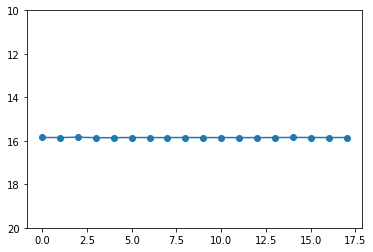

In [88]:
plt.plot(results, marker='o')

plt.ylim(20, 10)

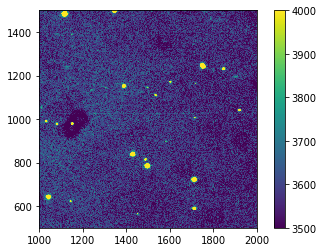

In [112]:
image= fits.open("O120308_0185.fits")
image_pixels = image[0].data

plt.imshow(image_pixels, vmin=3500, vmax=4000)
plt.colorbar()
plt.xlim(1000,2000)
plt.ylim(500,1500)

plt.scatter(row['xcentroid'], row['ycentroid'], alpha=0.3, color='red')
